# Drugs.com Preprocessing
Prepare the primary Drugs.com benchmark exactly as specified.

In [1]:
# DEV MODE keeps notebook runs small during development; set to False for full DGX experiments.
DEV_MODE = True
SAMPLE_SIZE = 10000

# Resolve the project root from either the repository root or notebooks/ directory.
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import the shared device and seed utilities required by the specification.
from utils.device import RANDOM_SEED, get_device, set_seed

set_seed(RANDOM_SEED)
DEVICE = get_device()


Selected device: CUDA (NVIDIA GeForce RTX 5070 Ti Laptop GPU)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Shared preprocessing utilities used identically across datasets.
import html
import re

LABEL2ID = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2LABEL = {0: "Negative", 1: "Neutral", 2: "Positive"}
NUM_CLASSES = 3


def clean_text(value):
    # Apply the exact text cleaning pipeline from the specification.
    if not isinstance(value, str):
        return ""
    text = value.lower()
    text = html.unescape(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s'-]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def label_from_rating_10(rating):
    # Map Drugs.com 1-10 ratings to Negative/Neutral/Positive labels.
    rating = float(rating)
    if 1 <= rating <= 4:
        return 0
    if 5 <= rating <= 6:
        return 1
    if 7 <= rating <= 10:
        return 2
    return None


def label_from_rating_5(rating):
    # Map 1-5 ratings to Negative/Neutral/Positive labels.
    rating = float(rating)
    if 1 <= rating <= 2:
        return 0
    if rating == 3:
        return 1
    if 4 <= rating <= 5:
        return 2
    return None


def label_from_effectiveness(value):
    # Map Druglib effectiveness text to the three-class label space.
    mapping = {
        "Ineffective": 0,
        "Marginally Effective": 1,
        "Moderately Effective": 1,
        "Considerably Effective": 2,
        "Highly Effective": 2,
    }
    return mapping.get(value, None)


def label_from_side_effects(value):
    # Map Druglib side-effect severity text to the three-class label space.
    mapping = {
        "Severe Side Effects": 0,
        "Extremely Severe Side Effects": 0,
        "Mild Side Effects": 1,
        "Moderate Side Effects": 1,
        "No Side Effects": 2,
    }
    return mapping.get(value, None)


## Load Raw Files
The train and test raw files are combined before any cleaning.

In [3]:
raw_dir = PROJECT_ROOT / "data/raw"
train_raw = pd.read_csv(raw_dir / "drugsComTrain_raw.csv")
test_raw = pd.read_csv(raw_dir / "drugsComTest_raw.csv")
df = pd.concat([train_raw, test_raw], ignore_index=True)
if DEV_MODE:
    df = df.head(SAMPLE_SIZE)
print("Combined shape:", df.shape)
print(df.dtypes)


Combined shape: (10000, 7)
uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object


## Inspect Missing Values, Duplicates, and Ratings

Null counts:
uniqueID        0
drugName        0
condition      59
review          0
rating          0
date            0
usefulCount     0
dtype: int64
Duplicate rows: 0


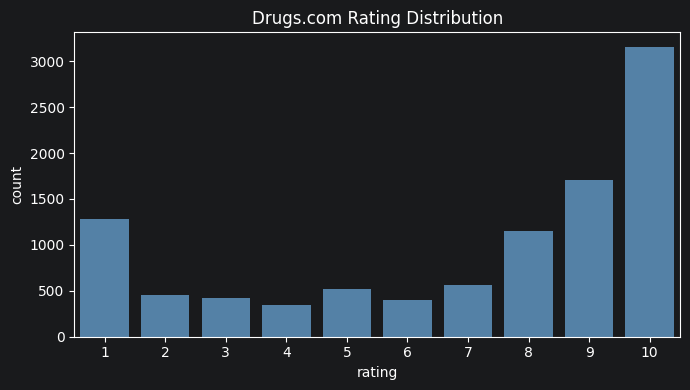

In [4]:
print("Null counts:")
print(df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="rating", color="steelblue")
plt.title("Drugs.com Rating Distribution")
plt.tight_layout()
plt.show()


## Clean Text and Assign Labels
Only `review` and `rating` are kept. Negations, numbers, and medical terms are preserved.

In [5]:
df = df[["review", "rating"]].dropna().drop_duplicates().copy()
df["review"] = df["review"].apply(clean_text)
df = df[df["review"].str.len() > 0].copy()
df["label"] = df["rating"].apply(label_from_rating_10)
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)
print(df.head(5))


                                              review  rating  label
0  it has no side effect i take it in combination...       9      2
1  my son is halfway through his fourth week of i...       8      2
2  i used to take another oral contraceptive whic...       5      1
3  this is my first time using any form of birth ...       8      2
4  suboxone has completely turned my life around ...       9      2


## Verify Distribution and Save

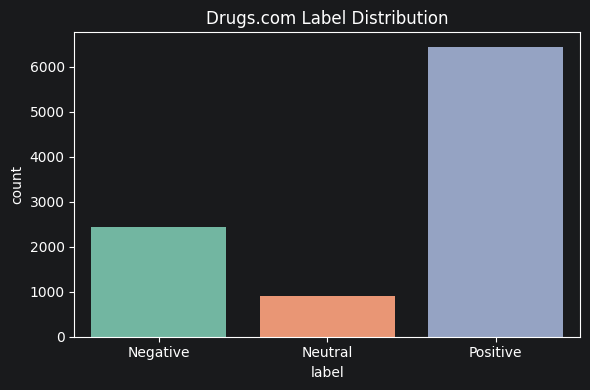

Sample cleaned reviews:


,review,rating,label
9801,i am currently laid in a ball in absolute agon...,1,0
7257,i had many different side effects that i know ...,1,0
4760,i love this i have had my implanon since march...,10,2
6297,left lexapro for viibryd first few weeks were ...,1,0
9031,i was taking 50 mg three times a day it worked...,8,2


Saved: D:\33333\MedSentiX\data\processed\drugs_com_clean.csv
Final shape: (9788, 3)
label
0    0.249796
1    0.091949
2    0.658255
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label", hue="label", palette="Set2", legend=False)
plt.xticks([0, 1, 2], ["Negative", "Neutral", "Positive"])
plt.title("Drugs.com Label Distribution")
plt.tight_layout()
plt.show()

print("Sample cleaned reviews:")
display(df[["review", "rating", "label"]].sample(min(5, len(df)), random_state=RANDOM_SEED))

output_path = PROJECT_ROOT / "data/processed/drugs_com_clean.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print("Saved:", output_path)
print("Final shape:", df.shape)
print(df["label"].value_counts(normalize=True).sort_index())
